## Датасет

In [1]:
%matplotlib inline
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
class HorsesHumansDataset(Dataset):
    def __init__(self, horse_dir, human_dir, transform=None):
        self.images = []
        self.labels = []

        default_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Загрузка изображений лошадей (класс 0)
        for filename in os.listdir(horse_dir):
            self.images.append(default_transform(Image.open(os.path.join(horse_dir, filename)).convert('RGB')))
            self.labels.append(0)

            if transform is not None:
                self.images.append(transform(self.images[-1]))
                self.labels.append(0)
        
        # Загрузка изображений людей (класс 1)
        for filename in os.listdir(human_dir):
            self.images.append(default_transform(Image.open(os.path.join(human_dir, filename)).convert('RGB')))
            self.labels.append(1)

            if transform is not None:
                self.images.append(transform(self.images[-1]))
                self.labels.append(1)
        
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # image_path = self.image_paths[idx]
        # image = Image.open(image_path).convert('RGB')
        # label = self.labels[idx]
        
        # if self.transform:
        #     image = self.transform(image)
        
        return self.images[idx], self.labels[idx]

# Аугментации
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.8, contrast=0.4, saturation=0.3, hue=0.4),
    transforms.RandomGrayscale(0.15),
    # transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Создание датасетов и загрузчиков
train_dataset = HorsesHumansDataset("horse-or-human\\train\horses", "horse-or-human\\train\humans", train_transform)
val_dataset = HorsesHumansDataset("horse-or-human\\validation\horses", "horse-or-human\\validation\humans", None)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")

Размер обучающей выборки: 2054
Размер валидационной выборки: 256


## Обучение

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
from typing import Literal

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
class CNN(nn.Module):
    def __init__(
            self,
            conv_channels: list[int] | tuple[int] | int = (32, 64, 128, 256), 
            kernel_size: list[int] | tuple[int] | int = (3, 3, 3, 3), 
            padding: list[int] | tuple[int] | int = (1, 1, 1, 1), 
            conv_activation: Literal['relu', 'sigmoid', 'tanh', 'leaky_relu'] = 'relu', 
            pooling: list[list[int]] | tuple[tuple[int]] | tuple[int] = ((2, 2), (2, 2), (2, 2), (2, 2)), 
            linear_dims: list[int] | tuple[int] | int | None = (512, 128), 
            linear_activation: Literal['relu', 'sigmoid', 'tanh', 'leaky_relu'] = 'relu',
            dropout: list[float] | tuple[float] | float | None = (0.5, 0.3),
        ):
        super(CNN, self).__init__()
        
        conv_activation = (
            nn.Sigmoid if conv_activation == 'sigmoid' 
            else nn.Tanh if conv_activation == 'tanh' 
            else nn.LeakyReLU if conv_activation == 'leaky_relu' 
            else nn.ReLU
        )
        linear_activation = (
            nn.Sigmoid if linear_activation == 'sigmoid' 
            else nn.Tanh if linear_activation == 'tanh' 
            else nn.LeakyReLU if linear_activation == 'leaky_relu' 
            else nn.ReLU
        )

        self.conv_layers = nn.Sequential()

        if isinstance(conv_channels, (list, tuple, np.ndarray, torch.Tensor)):
            for i in range(len(conv_channels)):
                self.conv_layers.add_module(f'conv{i+1}', nn.Conv2d(
                    3 if i == 0 else conv_channels[i-1], conv_channels[i], 
                    kernel_size=kernel_size[i], padding=padding[i]
                ))
                self.conv_layers.add_module(f'batch_norm{i+1}', nn.BatchNorm2d(conv_channels[i]))
                self.conv_layers.add_module(f'conv_activation{i+1}', conv_activation())
                self.conv_layers.add_module(f'maxpool{i+1}', nn.MaxPool2d(*pooling[i]))
        else:
            self.conv_layers = nn.Sequential(
                nn.Conv2d(3, conv_channels, kernel_size=kernel_size, padding=padding),
                nn.BatchNorm2d(conv_channels),
                conv_activation(),
                nn.MaxPool2d(pooling)
            )
        
        # Вычисляем размер после сверточных слоев
        self._to_linear = None
        self._get_conv_output((3, 300, 300))

        self.fc_layers = nn.Sequential()

        if linear_dims is None:
            self.fc_layers = nn.Sequential(
                nn.Linear(self._to_linear, 1),
                nn.Sigmoid()
            )
        elif isinstance(linear_dims, (list, tuple, np.ndarray, torch.Tensor)):
            for i in range(len(linear_dims)):
                self.fc_layers.add_module(f'linear{i+1}', nn.Linear(
                    self._to_linear if i == 0 else linear_dims[i-1], linear_dims[i]
                ))
                self.fc_layers.add_module(f'linear_activation{i+1}', linear_activation())
                if dropout is not None:
                    self.fc_layers.add_module(f'dropout{i+1}', nn.Dropout(
                        dropout if isinstance(dropout, float) else dropout[i]
                    ))
            
            self.fc_layers.add_module(f'linear{len(linear_dims) + 1}', nn.Linear(linear_dims[-1], 1))
            self.fc_layers.add_module('sigmoid', nn.Sigmoid())
        else:
            self.fc_layers = nn.Sequential(
                nn.Linear(self._to_linear, linear_dims),
                linear_activation(),
            )
            if dropout is not None:
                self.fc_layers.add_module('dropout1', nn.Dropout(dropout))


            self.fc_layers.add_module('linear2', nn.Linear(linear_dims, 1))
            self.fc_layers.add_module('sigmoid', nn.Sigmoid())

    
    def _get_conv_output(self, shape):
        input = torch.rand(1, *shape)
        output = self.conv_layers(input)
        self._to_linear = int(np.prod(output.size()[1:]))
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  
        x = self.fc_layers(x)
        return x
    

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                
                predicted = (outputs > 0.5).float()
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                all_probs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)
        
        all_probs = np.array(all_probs).flatten()
        all_labels = np.array(all_labels).flatten()
        roc_auc = roc_auc_score(all_labels, all_probs)
        
        scheduler.step()
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {epoch_loss:.4f}')
        print(f'  Val Loss: {epoch_val_loss:.4f}')
        print(f'  Val Accuracy: {epoch_val_acc:.4f}')
        print(f'  ROC-AUC: {roc_auc:.4f}')
        print(f'  Learning Rate: {scheduler.get_last_lr()[0]:.6f}')
    
    return train_losses, val_losses, val_accuracies


In [8]:
model = CNN(
    [32, 64, 64, 128], [3, 3, 3, 3], [1, 1, 1, 1,], 
    'leaky_relu', [(2, 2), (2, 2), (2, 2), (2, 2)], 
    512, 'relu', dropout=0.3
).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
torch.cuda.empty_cache()

In [9]:
train_losses, val_losses, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=15
)

Epoch 1/15:
  Train Loss: 13.0725
  Val Loss: 19.2456
  Val Accuracy: 0.7539
  ROC-AUC: 0.7820
  Learning Rate: 0.001000
Epoch 2/15:
  Train Loss: 7.7718
  Val Loss: 23.4919
  Val Accuracy: 0.6953
  ROC-AUC: 0.7406
  Learning Rate: 0.001000
Epoch 3/15:
  Train Loss: 8.0040
  Val Loss: 19.2131
  Val Accuracy: 0.7773
  ROC-AUC: 0.7299
  Learning Rate: 0.001000
Epoch 4/15:
  Train Loss: 7.7765
  Val Loss: 25.1431
  Val Accuracy: 0.7383
  ROC-AUC: 0.7480
  Learning Rate: 0.001000
Epoch 5/15:
  Train Loss: 5.9639
  Val Loss: 19.6017
  Val Accuracy: 0.7617
  ROC-AUC: 0.7892
  Learning Rate: 0.000500
Epoch 6/15:
  Train Loss: 4.7603
  Val Loss: 7.4393
  Val Accuracy: 0.8711
  ROC-AUC: 0.8586
  Learning Rate: 0.000500
Epoch 7/15:
  Train Loss: 5.7077
  Val Loss: 12.4690
  Val Accuracy: 0.8320
  ROC-AUC: 0.8488
  Learning Rate: 0.000500
Epoch 8/15:
  Train Loss: 5.0502
  Val Loss: 11.4195
  Val Accuracy: 0.8359
  ROC-AUC: 0.8238
  Learning Rate: 0.000500
Epoch 9/15:
  Train Loss: 3.7945
  Val L

In [11]:
with torch.no_grad():
    Y = [(model(images.to(device)).cpu(), labels.float().unsqueeze(1)) for images, labels in val_loader]
    y_pred = torch.cat([Y[i][0] for i in range(len(Y))], dim=0)
    y = torch.cat([Y[i][1] for i in range(len(Y))], dim=0)


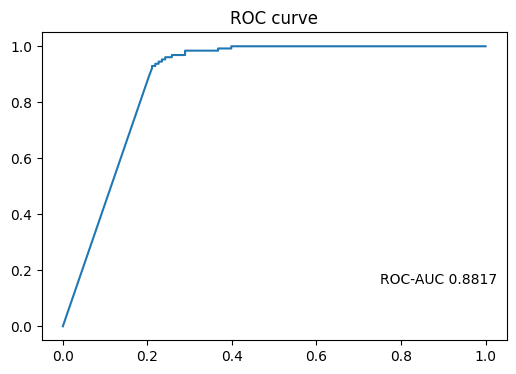

In [19]:
roc_auc = roc_auc_score(y, y_pred)
fpr, tpr, _ = roc_curve(y, y_pred)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr)
plt.title("ROC curve")
plt.text(0.75, 0.15, f"ROC-AUC {roc_auc:.4f}");

In [ ]:
# torch.save(model.state_dict(), 'horse_human_model.pth')

## Интерфейс

In [6]:
import tkinter as tk
from tkinter import filedialog, messagebox, ttk
from PIL import ImageTk

In [ ]:
class ClassifierInterface:
    def __init__(self, root):
        self.root = root
        self.root.title("Классификатор: Лошадь или Человек")
        self.root.geometry("500x600")
        
        # Загрузка обученной модели
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CNN(
            [32, 64, 64, 128], [3, 3, 3, 3], [1, 1, 1, 1,], 
            'leaky_relu', [(2, 2), (2, 2), (2, 2), (2, 2)], 
            512, 'relu', dropout=0.3
        ).to(self.device)
        self.model.load_state_dict(torch.load('horse_human_model.pth', map_location=self.device))
        self.model.eval()
        
        self.transform = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.setup_ui()
    
    def setup_ui(self):
        # Заголовок
        title_label = tk.Label(
            self.root,
            text="Классификатор: Лошадь или Человек",
            font=("Arial", 16, "bold"),
            pady=6
        )
        title_label.pack()
        
        # Фрейм для изображения
        self.image_frame = tk.Frame(self.root, relief=tk.SUNKEN, borderwidth=2)
        self.image_frame.pack(pady=16, padx=20, fill=tk.BOTH, expand=True)
        
        # Метка для изображения
        self.image_label = tk.Label(self.image_frame, text="Изображение не загружено", bg="lightgray")
        self.image_label.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # Фрейм для кнопок
        button_frame = tk.Frame(self.root)
        button_frame.pack(pady=10)
        
        # Кнопка загрузки изображения
        load_button = tk.Button(
            button_frame,
            text="Загрузить изображение",
            command=self.load_image,
            width=20,
            height=2,
            bg="#4CAF50",
            fg="white",
            font=("Arial", 10)
        )
        load_button.pack(side=tk.LEFT, padx=10)
        
        # Кнопка классификации
        classify_button = tk.Button(
            button_frame,
            text="Классифицировать",
            command=self.classify_image,
            width=20,
            height=2,
            bg="#2196F3",
            fg="white",
            font=("Arial", 10)
        )
        classify_button.pack(side=tk.LEFT, padx=10)
        
        # Фрейм для результатов
        result_frame = tk.Frame(self.root, relief=tk.GROOVE, borderwidth=2)
        result_frame.pack(pady=16, padx=20, fill=tk.X)
        
        # Заголовок результатов
        result_title = tk.Label(
            result_frame,
            text="Результаты классификации",
            font=("Arial", 12, "bold"),
            bg="#f0f0f0"
        )
        result_title.pack(fill=tk.X, pady=5)
        
        # Метка для результата
        self.result_label = tk.Label(
            result_frame,
            text="Ожидание загрузки изображения...",
            font=("Arial", 11),
            wraplength=450,
            justify=tk.LEFT
        )
        self.result_label.pack(pady=10, padx=10)
        
        self.confidence_frame = tk.Frame(result_frame)
        self.confidence_frame.pack(pady=10, padx=10, fill=tk.X)
        
        self.confidence_label = tk.Label(
            self.confidence_frame,
            text="Уверенность модели:",
            font=("Arial", 10)
        )
        self.confidence_label.pack(anchor=tk.W)
        
        self.progress = ttk.Progressbar(
            self.confidence_frame,
            length=250,
            mode='determinate',
            maximum=100
        )
        self.progress.pack(pady=5)
        
        self.confidence_value = tk.Label(
            self.confidence_frame,
            text="0%",
            font=("Arial", 10, "bold")
        )
        self.confidence_value.pack()
    
    def load_image(self):
        file_path = filedialog.askopenfilename(
            title="Выберите изображение",
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
        )
        
        if file_path:
            try:
                image = Image.open(file_path)
                image.thumbnail((350, 350))
                photo = ImageTk.PhotoImage(image)
                
                self.image_label.config(image=photo, text="")
                self.image_label.image = photo
                
                self.current_image_path = file_path
                self.result_label.config(text="Изображение загружено. Нажмите 'Классифицировать'.")
                
            except Exception as e:
                messagebox.showerror("Ошибка", f"Не удалось загрузить изображение: {str(e)}")
    
    def classify_image(self):
        if not hasattr(self, 'current_image_path'):
            messagebox.showwarning("Предупреждение", "Сначала загрузите изображение!")
            return
        
        try:
            image = Image.open(self.current_image_path).convert('RGB')
            image_tensor = self.transform(image).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                output = self.model(image_tensor)
                probability = output.item()
            
            if probability > 0.5:
                class_name = "ЧЕЛОВЕК"
                confidence = probability * 100
                color = "#2196F3"
            else:
                class_name = "ЛОШАДЬ"
                confidence = (1 - probability) * 100
                color = "#795548" 
            
            self.result_label.config(
                text=f"Результат: {class_name} с вероятностью {confidence:.1f}%",
                fg=color
            )
            
            self.progress['value'] = confidence
            self.confidence_value.config(text=f"{confidence:.1f}%")
            
        except Exception as e:
            messagebox.showerror("Ошибка", f"Ошибка классификации: {str(e)}")


In [18]:
root = tk.Tk()
app = ClassifierInterface(root)
root.mainloop()